# Projet de Data Science – Ames Banking Group
## Estimation de la valeur immobilière pour l'aide à la décision hypothécaire
*Document de synthèse — Démarche CRISP-ML complète*

---

**Contexte :** La banque *Ames Banking Group* souhaite outiller ses conseillers pour estimer la valeur d'un bien immobilier lors d'une demande de prêt hypothécaire, en remplacement du traitement manuel actuel, jugé chronophage et source de biais humains.

**Objectif du notebook final :** consolider les résultats des notebooks individuels du groupe, comparer les modèles selon des critères communs et justifier le choix final.

**Modèle retenu :** **XGBoost**, après comparaison avec la baseline M0, Lasso, ElasticNet, Random Forest et Neural Network.

**Résumé du choix :** le choix final se joue surtout entre **ElasticNet** et **XGBoost**. ElasticNet est plus simple, plus léger et très interprétable, mais XGBoost obtient le meilleur RMSE interne et le meilleur écart métier parmi les modèles candidats. Pour une banque, nous retenons donc XGBoost comme modèle final, tout en documentant le coût IT plus élevé et la nécessité de monitoring.

---

> **Structure du document**
>
> 1. Compréhension métier
> 2. Data Understanding
> 3. Data Preparation
> 4. Model Engineering
> 5. Évaluation comparative
> 6. Choix final
> 7. Déploiement théorique, monitoring et éthique


## Phase 0 - ML Canvas simplifie et baseline commune

Avant de tester les modeles, nous avons defini le probleme metier a resoudre et le cadre d'evaluation commun du groupe.

### Probleme metier

Le projet cherche a estimer le prix de vente d'un bien immobilier a partir de ses caracteristiques. Dans notre use case, cette estimation peut aider une banque dans l'analyse d'un dossier hypothecaire.

L'objectif est de fournir une estimation coherente et objectivable du prix d'un bien afin de limiter les erreurs d'evaluation, notamment le risque de surestimation.

### Utilisateurs cibles

Les utilisateurs cibles sont principalement :

- les conseillers bancaires ;
- les analystes credit ;
- les equipes de gestion du risque.

### Donnees disponibles

Nous utilisons les donnees du challenge Kaggle **House Prices - Advanced Regression Techniques**.

Le dataset contient des informations sur les biens immobiliers, par exemple :

- la surface habitable ;
- la qualite generale du bien ;
- le quartier ;
- l'annee de construction ;
- le garage ;
- le sous-sol ;
- les salles de bain ;
- les conditions de vente.

La variable cible est **SalePrice**, c'est-a-dire le prix de vente final du bien immobilier.

### Proposition de valeur

La proposition de valeur est d'aider la banque a obtenir une estimation plus fiable du prix d'un bien immobilier.

Cette estimation peut servir d'aide a la decision dans le cadre d'un pret hypothecaire. Elle ne remplace pas l'expertise humaine, mais elle permet de fournir un point de comparaison objectif et reproductible.

### Risques principaux

Les principaux risques identifies sont :

- la surestimation du prix d'un bien ;
- les biais lies au quartier ou a certaines caracteristiques geographiques ;
- la derive du marche immobilier dans le temps ;
- la difficulte a expliquer certains modeles complexes ;
- le risque d'utiliser le modele comme decision automatique au lieu d'un outil d'aide.

### Mesures de succes

Pour evaluer les modeles, nous utilisons plusieurs criteres :

- le **RMSE log**, qui mesure l'erreur mathematique ;
- le **score Kaggle**, qui permet une comparaison officielle ;
- l'erreur en prix reel, plus comprehensible metier ;
- l'ecart median en pourcentage ;
- le temps d'entrainement ;
- l'interpretabilite du modele.

### Role de la baseline M0

La baseline M0 constitue le point de comparaison commun du groupe.

Elle permet d'evaluer si les modeles plus avances apportent une vraie amelioration par rapport a une approche simple.

Cette baseline repose sur une regression lineaire avec quelques variables metier importantes. Elle sert de reference pour comparer les modeles suivants :

- Lasso ;
- ElasticNet ;
- Random Forest ;
- XGBoost ;
- Neural Network.

L'objectif n'est donc pas uniquement d'obtenir un bon score Kaggle, mais de montrer une progression structuree depuis un modele simple vers des modeles plus avances.

# 1. Compréhension métier
*CRISP-ML — Phase 1 : Business Understanding*

Le besoin métier est d'estimer le prix de vente réaliste d'une maison afin d'aider les conseillers bancaires lors d'une demande de prêt hypothécaire.

Lorsqu'un client sollicite un prêt, le conseiller saisit les caractéristiques du bien immobilier dans le système. Le modèle prédit alors le prix de marché du bien et compare cette estimation au montant du prêt demandé pour recommander une décision.

La banque dispose d'un entrepôt de données alimenté par l'historique des transactions et chaque nouvelle vente enregistrée au cadastre de la ville d'Ames — une source suffisamment riche pour entraîner un modèle supervisé.

**Contrainte de risque asymétrique :**

- Une **surestimation** est le risque principal : la banque prêterait un montant supérieur à la valeur réelle du bien. En cas de défaut de paiement, elle ne pourrait pas récupérer l'intégralité de son exposition via la saisie et la revente du bien.
- Une **sous-estimation modérée** est acceptable côté banque, mais ne doit pas être excessive pour éviter de refuser de bons dossiers ou de perdre des parts de marché face à la concurrence.

> **Contrainte métier :** le modèle doit produire une estimation fiable avec une attention particulière portée aux surestimations. La banque appliquera ensuite une marge de sécurité configurable sur la valeur estimée avant de statuer sur le montant du prêt accordable.

# 2. Les trois piliers de la Data Science
*CRISP-ML — Ancrage interdisciplinaire*

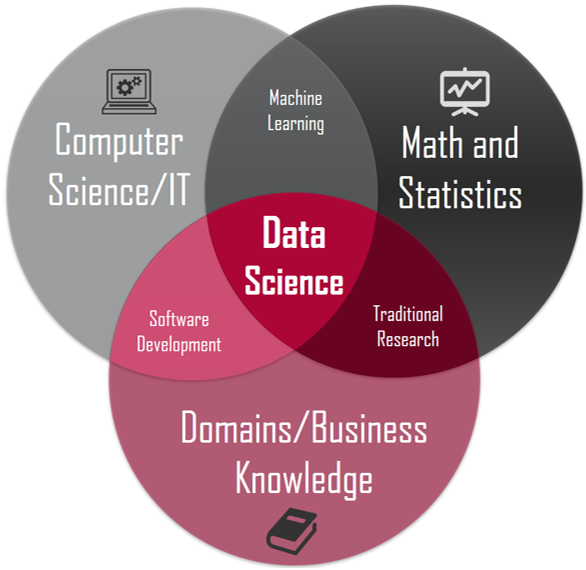

## Business
- Estimer le prix de vente d'une maison pour orienter la décision d'octroi de prêt hypothécaire.
- Réduire le temps de traitement manuel des conseillers et limiter les biais humains.
- Limiter le risque financier en cas de défaut de paiement, grâce à une estimation cohérente avec le marché.
- Intégrer une marge de sécurité configurable (X %) sur la prédiction finale — point d'attention : une marge trop élevée ferait fuir les clients vers la concurrence.

## Mathématiques & Statistiques
- Analyse de la distribution de `SalePrice` : asymétrie droite (*right-skewed*), correction par transformation logarithmique `np.log1p`.
- Traitement de la multicolinéarité : suppression des variables sources après création des variables agrégées (feature engineering), pour ne pas fausser les poids statistiques.
- Encodage ordinal des variables de qualité : respect de l'ordre logique `Po < Fa < TA < Gd < Ex`.
- Évaluation via RMSE sur la cible transformée (cohérent avec la métrique RMSLE de Kaggle), complétée par une lecture métier en pourcentage d'écart médian.
- Comparaison de quatre modèles : Lasso, ElasticNet, Random Forest, XGBoost,Neurone net.

## IT
- Construction de pipelines `sklearn` reproductibles, reconstruits à chaque pli de validation croisée pour prévenir tout *data leakage*.
- Utilisation du `TargetEncoder` (`category_encoders`) pour la variable `Neighborhood` : chaque quartier est remplacé par la moyenne lissée de `SalePrice` pour ce quartier — plus précis qu'un encodage One-Hot sur une variable à forte cardinalité.
- Optimisation automatique des hyperparamètres via **Optuna** (optimisation bayésienne, 80 essais).
- Suivi des expérimentations avec **MLflow** (métriques, paramètres, versions).
- Architecture orientée vers un déploiement futur via API REST.

In [1]:
# Imports généraux

import warnings
warnings.filterwarnings("ignore")

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, median_absolute_error, mean_absolute_error

from sklearn.linear_model import ElasticNetCV, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.base import clone

try:
    from xgboost import XGBRegressor
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print("XGBoost non disponible.")

RANDOM_STATE = 42

# Le notebook final est un document de synthèse.
# Les scores officiels proviennent des notebooks individuels.
# Pour éviter un temps d’exécution trop long, les cellules de démonstration XGBoost utilisent une version allégée.
RUN_FINAL_SUBMISSION = False
XGB_N_ESTIMATORS_DEMO = 150

In [2]:
# TargetMeanEncoder maison — remplacement de category_encoders.TargetEncoder
# Objectif : rendre le notebook exécutable sans dépendance externe category_encoders.
# Principe : chaque catégorie est remplacée par la moyenne lissée de log1p(SalePrice)
# observée dans le fold d'entraînement. Cela évite le OneHotEncoder massif et limite le data leakage.

class TargetMeanEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, smoothing=10):
        self.smoothing = smoothing

    def fit(self, X, y):
        X_df = pd.DataFrame(X).copy()
        y_series = pd.Series(y, index=X_df.index)
        self.columns_ = X_df.columns.tolist()
        self.global_mean_ = float(y_series.mean())
        self.mappings_ = {}

        for col in self.columns_:
            s = X_df[col].astype(str).fillna("Missing")
            stats = pd.DataFrame({"cat": s, "target": y_series}).groupby("cat")["target"].agg(["mean", "count"])
            smooth = (stats["count"] * stats["mean"] + self.smoothing * self.global_mean_) / (stats["count"] + self.smoothing)
            self.mappings_[col] = smooth.to_dict()
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X).copy()
        encoded = pd.DataFrame(index=X_df.index)
        for col in self.columns_:
            s = X_df[col].astype(str).fillna("Missing")
            encoded[col] = s.map(self.mappings_[col]).fillna(self.global_mean_).astype(float)
        return encoded.values


# 3. Chargement des données
*CRISP-ML — Phase 2 : Data Understanding*

Le dataset provient de la compétition Kaggle *House Prices: Advanced Regression Techniques*, basée sur les ventes immobilières à Ames, Iowa. Il comprend 79 colonnes (critères) permettant d'estimer le prix de vente.

| Fichier | Observations | Variable cible | Rôle |
|---|---|---|---|
| `train.csv` | 1 460 | `SalePrice` présent | Entraînement et validation |
| `test.csv` | 1 459 | `SalePrice` absent | Prédiction finale / soumission Kaggle |

In [3]:
# Chargement robuste des fichiers Kaggle
# Le notebook cherche d'abord les CSV dans le dossier courant ou Data/.
# Si les CSV ne sont pas présents, il lit directement le ZIP Kaggle.

import zipfile
from pathlib import Path

possible_dirs = [Path("."), Path("Data"), Path("house_prices_data"), Path("/mnt/data/house_prices_data3"), Path("/mnt/data/house_prices_data")]
train = test = sample_submission = None

for data_dir in possible_dirs:
    if (data_dir / "train.csv").exists() and (data_dir / "test.csv").exists():
        print(f"Données chargées depuis : {data_dir.resolve()}")
        train = pd.read_csv(data_dir / "train.csv")
        test = pd.read_csv(data_dir / "test.csv")
        if (data_dir / "sample_submission.csv").exists():
            sample_submission = pd.read_csv(data_dir / "sample_submission.csv")
        break

if train is None:
    zip_candidates = list(Path(".").glob("house-prices-advanced-regression-techniques*.zip")) + list(Path("/mnt/data").glob("house-prices-advanced-regression-techniques*.zip"))
    if not zip_candidates:
        raise FileNotFoundError("Impossible de trouver train.csv/test.csv ou le ZIP Kaggle.")
    zip_path = zip_candidates[0]
    print(f"Lecture depuis le ZIP : {zip_path}")
    with zipfile.ZipFile(zip_path, "r") as z:
        train = pd.read_csv(z.open("train.csv"))
        test = pd.read_csv(z.open("test.csv"))
        sample_submission = pd.read_csv(z.open("sample_submission.csv"))

print("Dimensions train :", train.shape)
print("Dimensions test  :", test.shape)
display(train.head())


Données chargées depuis : C:\data_science\Data
Dimensions train : (1460, 81)
Dimensions test  : (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# 4. Analyse exploratoire de la variable cible
*CRISP-ML — Phase 2 : Data Understanding*

## Distribution des prix

La variable cible `SalePrice` présente une distribution asymétrique vers la droite (*right-skewed*) : la grande majorité des transactions se situe entre 100 000 $ et 250 000 $, puis la courbe s'étire vers des biens plus luxueux.

En entraînant le modèle sur ces valeurs brutes, les quelques biens à prix élevés influenceraient excessivement l'apprentissage, poussant le modèle à surestimer — ce qui est précisément le risque que la banque cherche à éviter.

En appliquant une transformation logarithmique `np.log1p`, les valeurs extrêmes sont « écrasées » et on obtient une distribution proche d'une loi normale. Le modèle apprend alors à minimiser des **écarts proportionnels** plutôt qu'absolus — cohérent avec le RMSLE utilisé par Kaggle.

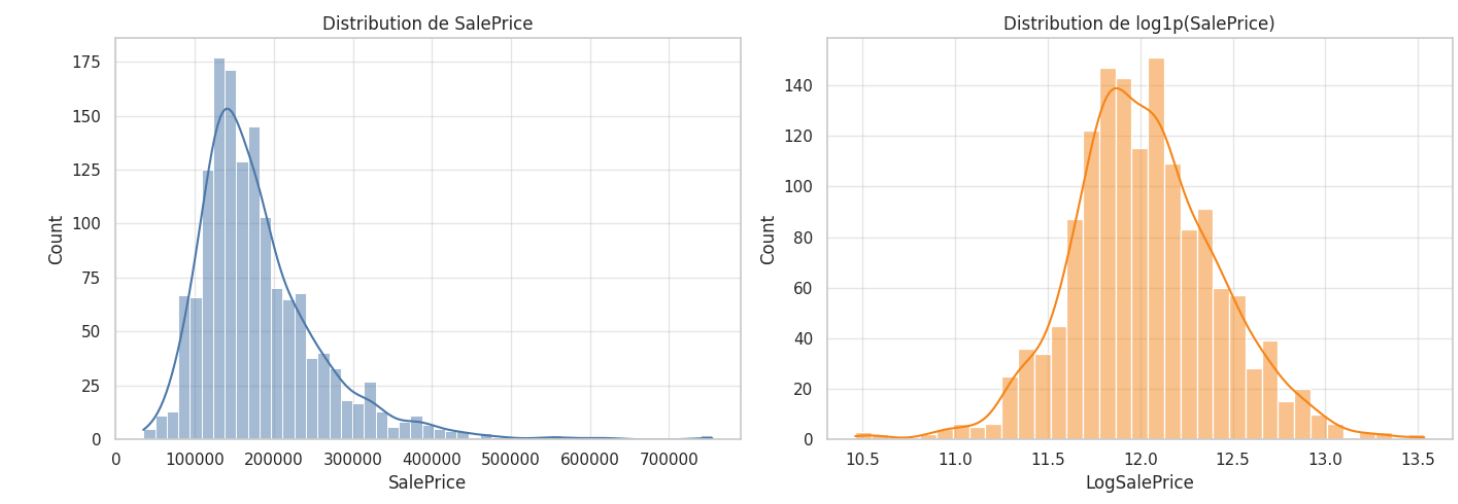

## Analyse des variables importantes

Afin de sélectionner les variables les plus pertinentes, une analyse de corrélation (Pearson et Spearman) a été réalisée sur les variables numériques par rapport à `log1p(SalePrice)`.

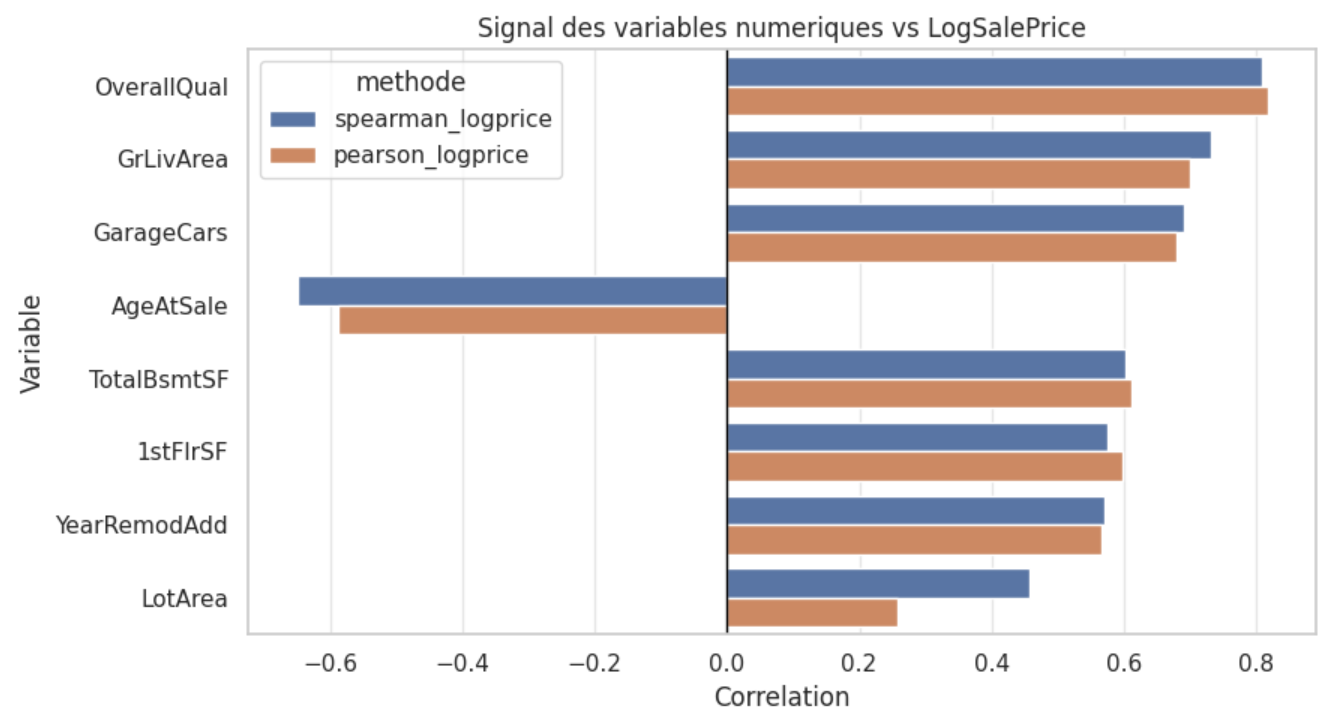

`OverallQual` et `GrLivArea` se détachent nettement comme les deux variables numériques les plus corrélées au prix. `AgeAtSale` (variable dérivée) présente une corrélation négative significative : plus une maison est ancienne, plus son prix tend à être bas.

## Analyse des variables catégorielles

Pour les variables catégorielles, la médiane des prix de vente par modalité a été analysée.

**Distribution par quartier (`Neighborhood`) :**

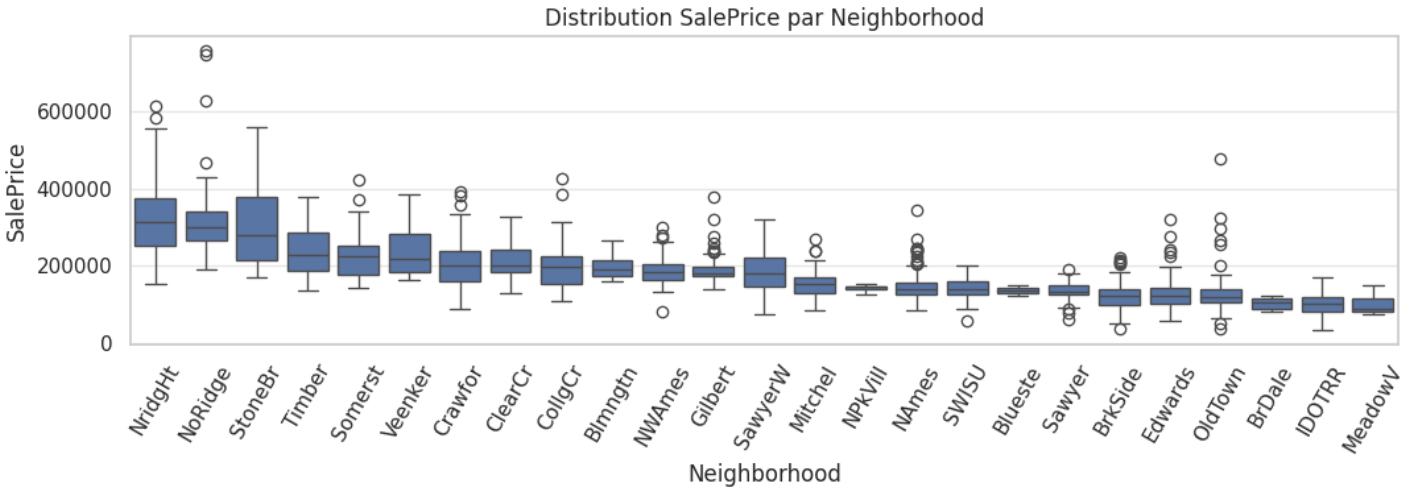

L'écart de prix médian entre les quartiers les plus chers (NridgHt, NoRidge, StoneBr) et les moins chers (MeadowV, IDOTRR, BrDale) est très significatif. C'est la justification principale du **Target Encoding** pour cette variable plutôt qu'un One-Hot simple.

**Distribution par qualité de cuisine (`KitchenQual`) :**

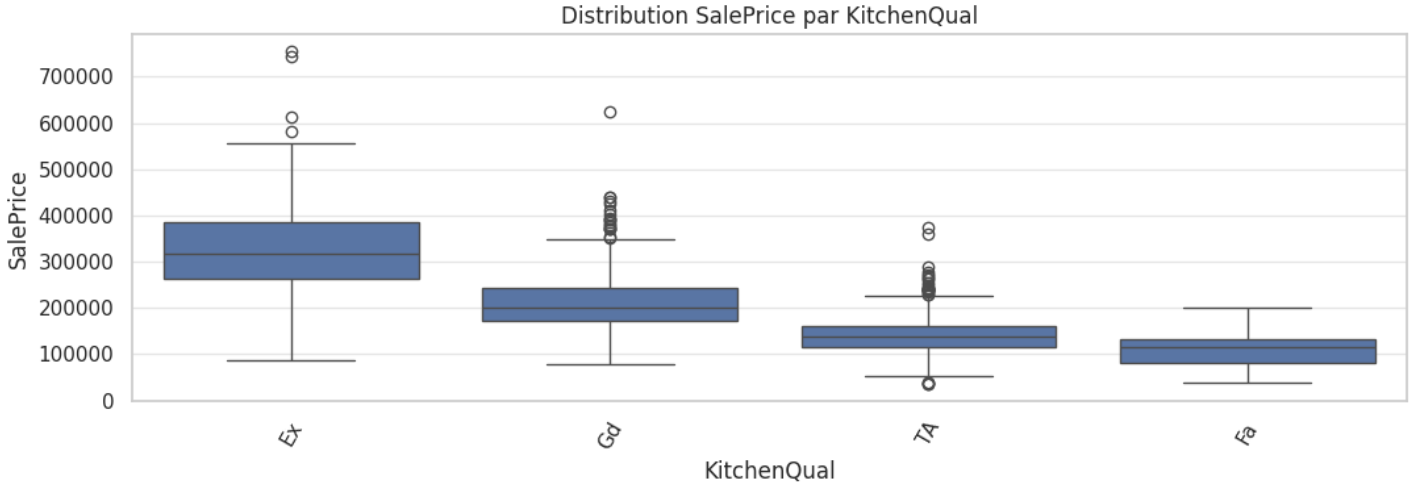

La progression de prix entre les modalités `Fa → TA → Gd → Ex` est claire et ordonnée, ce qui justifie l'**encodage ordinal** plutôt qu'un encodage nominal.

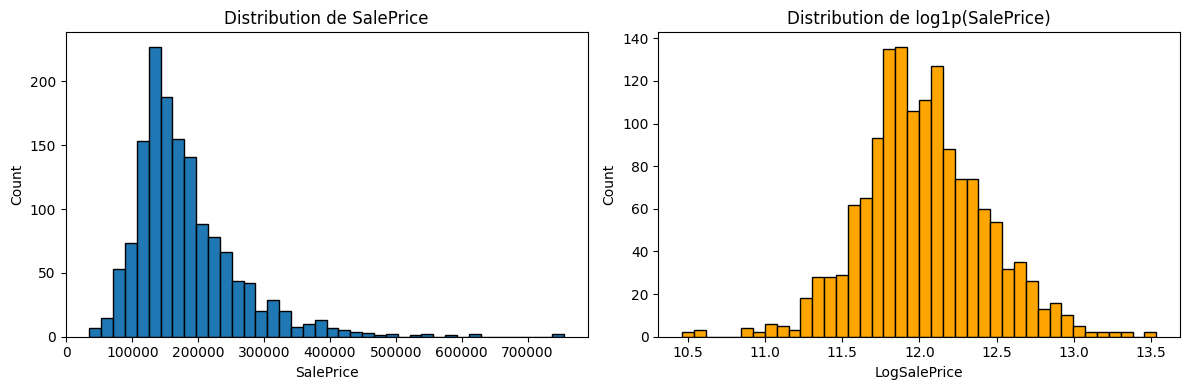

In [4]:
# Reproduction du graphique de distribution (exécutable si les données sont disponibles)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(train["SalePrice"], bins=40, edgecolor="black")
ax1.set_title("Distribution de SalePrice")
ax1.set_xlabel("SalePrice")
ax1.set_ylabel("Count")

ax2.hist(np.log1p(train["SalePrice"]), bins=40, edgecolor="black", color="orange")
ax2.set_title("Distribution de log1p(SalePrice)")
ax2.set_xlabel("LogSalePrice")
ax2.set_ylabel("Count")

plt.tight_layout()
plt.show()

# 5. Feature engineering
*CRISP-ML — Phase 3 : Data Preparation*

Le feature engineering est entièrement **déterministe** : il n'utilise jamais la variable cible et peut donc être appliqué à l'identique sur train et test, sans risque de *data leakage*.

**A — Surfaces et compteurs manquants → 0**
L'absence de valeur sur une surface de garage ou de sous-sol traduit l'absence de l'équipement.

**B — Encodage ordinal des variables de qualité**
Les notes textuelles sont converties en entiers ordonnés respectant la hiérarchie logique :

| Code | Signification | Valeur |
|---|---|---|
| Ex | Excellent | 5 |
| Gd | Good | 4 |
| TA | Typical / Average | 3 |
| Fa | Fair | 2 |
| Po | Poor | 1 |
| None / Absent | Équipement inexistant | 0 |

On distingue les équipements *pouvant être absents* (manquant → `0`) des équipements *toujours présents* (manquant → `3`).

**C — Variables agrégées**

| Variable créée | Construction | Logique métier |
|---|---|---|
| `TotalSF` | `TotalBsmtSF + 1stFlrSF + 2ndFlrSF` | Surface totale habitable |
| `TotalBath` | `FullBath + 0.5×HalfBath + BsmtFullBath + 0.5×BsmtHalfBath` | Nombre de salles de bain pondéré |
| `TotalPorchSF` | Somme de toutes les surfaces de porche | Surface extérieure couverte |
| `QualxArea` | `OverallQual × GrLivArea` | Interaction qualité × surface |
| `IsRemodeled` | `YearBuilt != YearRemodAdd` | Indicateur binaire de rénovation |
| `HasGarage` | `GarageArea > 0` | Présence d'un garage |
| `HasBsmt` | `TotalBsmtSF > 0` | Présence d'un sous-sol |
| `HasFireplace` | `Fireplaces > 0` | Présence d'une cheminée |
| `HasPool` | `PoolArea > 0` | Présence d'une piscine |

**D — Âges relatifs** (plus parlants que les années brutes)

| Variable créée | Construction |
|---|---|
| `AgeBuilt` | `YrSold − YearBuilt` |
| `AgeRemodAdd` | `YrSold − YearRemodAdd` |
| `AgeGarage` | `YrSold − GarageYrBlt` |

**E — Suppression des variables sources**
`YearBuilt`, `YearRemodAdd` et `GarageYrBlt` sont supprimées après création des âges pour éliminer la redondance et la multicolinéarité.

In [5]:
# Feature engineering — aligné sur le notebook M4 XGBoost

def feature_engineering(data):
    df = data.copy()

    df["MSSubClass"] = df["MSSubClass"].astype(str)

    # A. Surfaces / compteurs absents -> 0
    zero_fill = ["MasVnrArea", "GarageArea", "GarageCars", "TotalBsmtSF",
                 "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "BsmtFullBath", "BsmtHalfBath"]
    for c in zero_fill:
        if c in df.columns:
            df[c] = df[c].fillna(0)

    # Année du garage manquante -> année de construction ; correction si postérieure à la vente
    df["GarageYrBlt"] = df["GarageYrBlt"].fillna(df["YearBuilt"])
    df["GarageYrBlt"] = df["GarageYrBlt"].clip(upper=df["YrSold"])

    # B. Encodage ordinal des qualités (Po < Fa < TA < Gd < Ex)
    qual_map = {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1, "None": 0}

    for c in ["BsmtQual", "BsmtCond", "FireplaceQu", "GarageQual", "GarageCond", "PoolQC"]:
        if c in df.columns:
            df[c] = df[c].map(qual_map).fillna(0)   # équipements pouvant être absents

    for c in ["ExterQual", "ExterCond", "HeatingQC", "KitchenQual"]:
        if c in df.columns:
            df[c] = df[c].map(qual_map).fillna(3)   # équipements toujours présents -> TA

    df["BsmtExposure"] = df["BsmtExposure"].map({"Gd": 4, "Av": 3, "Mn": 2, "No": 1, "None": 0}).fillna(0)
    fin_map = {"GLQ": 6, "ALQ": 5, "BLQ": 4, "Rec": 3, "LwQ": 2, "Unf": 1, "None": 0}
    df["BsmtFinType1"] = df["BsmtFinType1"].map(fin_map).fillna(0)
    df["BsmtFinType2"] = df["BsmtFinType2"].map(fin_map).fillna(0)
    df["GarageFinish"] = df["GarageFinish"].map({"Fin": 3, "RFn": 2, "Unf": 1, "None": 0}).fillna(0)
    df["Functional"] = df["Functional"].map(
        {"Typ": 7, "Min1": 6, "Min2": 5, "Mod": 4, "Maj1": 3, "Maj2": 2, "Sev": 1, "Sal": 0}).fillna(7)

    # C. Variables agrégées
    df["TotalSF"]      = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]
    df["TotalBath"]    = df["FullBath"] + 0.5*df["HalfBath"] + df["BsmtFullBath"] + 0.5*df["BsmtHalfBath"]
    df["TotalPorchSF"] = (df["OpenPorchSF"] + df["EnclosedPorch"] + df["3SsnPorch"]
                          + df["ScreenPorch"] + df["WoodDeckSF"])
    df["QualxArea"]    = df["OverallQual"] * df["GrLivArea"]
    df["IsRemodeled"]  = (df["YearBuilt"] != df["YearRemodAdd"]).astype(int)
    df["HasGarage"]    = (df["GarageArea"] > 0).astype(int)
    df["HasBsmt"]      = (df["TotalBsmtSF"] > 0).astype(int)
    df["HasFireplace"] = (df["Fireplaces"] > 0).astype(int)
    df["HasPool"]      = (df["PoolArea"] > 0).astype(int)

    # D. Âges relatifs (bornés à 0)
    df["AgeBuilt"]    = (df["YrSold"] - df["YearBuilt"]).clip(lower=0)
    df["AgeRemodAdd"] = (df["YrSold"] - df["YearRemodAdd"]).clip(lower=0)
    df["AgeGarage"]   = (df["YrSold"] - df["GarageYrBlt"]).clip(lower=0)

    # E. Suppression des variables sources (redondantes après création des âges)
    df = df.drop(["YearBuilt", "YearRemodAdd", "GarageYrBlt"], axis=1)

    # F. Catégories absentes -> 'None'
    for c in ["Alley", "Fence", "MiscFeature", "GarageType", "MasVnrType"]:
        if c in df.columns:
            df[c] = df[c].fillna("None")

    return df


train_fe = feature_engineering(train)
test_fe  = feature_engineering(test)

print("Dimensions train après feature engineering :", train_fe.shape)
print("Dimensions test  après feature engineering :", test_fe.shape)

Dimensions train après feature engineering : (1460, 90)
Dimensions test  après feature engineering : (1459, 89)


# 6. Suppression des outliers
*CRISP-ML — Phase 3 : Data Preparation*

Le dataset contient deux maisons avec une surface habitable très élevée (`GrLivArea > 4 000 sqft`) mais un prix de vente anormalement bas (< 300 000 $). Ces anomalies documentées par Dean De Cock ([jse.amstat.org/v19n3/decock.pdf](https://jse.amstat.org/v19n3/decock.pdf)) cassent la relation logique entre surface et prix.

**Seuil appliqué :** `GrLivArea > 4 000` ET `SalePrice < 300 000` → suppression du jeu d'entraînement uniquement. Le jeu de test n'est jamais modifié, Kaggle attendant une prédiction pour chaque `Id`.

Outliers détectés : 2


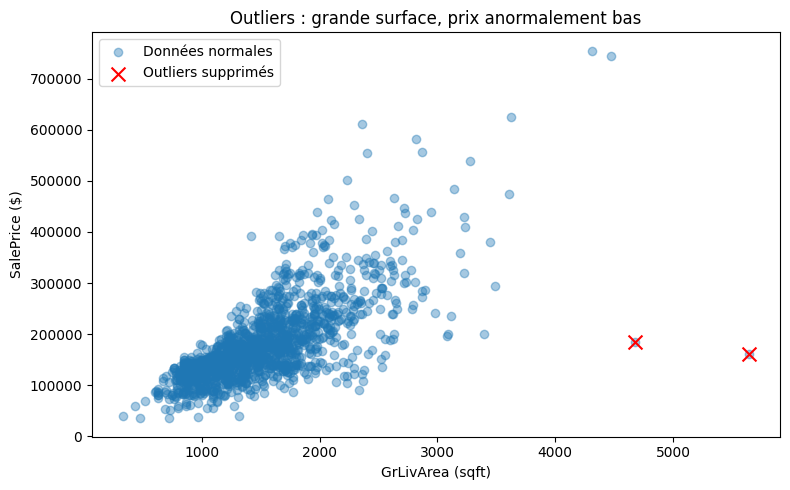

Dimensions train après suppression : (1458, 90)


In [6]:
# Suppression des outliers — uniquement sur le train

outlier_mask = (train_fe["GrLivArea"] > 4000) & (train_fe["SalePrice"] < 300000)
print(f"Outliers détectés : {outlier_mask.sum()}")

plt.figure(figsize=(8, 5))
plt.scatter(train_fe["GrLivArea"], train_fe["SalePrice"], alpha=0.4, label="Données normales")
plt.scatter(train_fe.loc[outlier_mask, "GrLivArea"],
            train_fe.loc[outlier_mask, "SalePrice"],
            color="red", marker="x", s=100, label="Outliers supprimés")
plt.xlabel("GrLivArea (sqft)")
plt.ylabel("SalePrice ($)")
plt.title("Outliers : grande surface, prix anormalement bas")
plt.legend()
plt.tight_layout()
plt.show()

train_fe = train_fe.loc[~outlier_mask].reset_index(drop=True)
print(f"Dimensions train après suppression : {train_fe.shape}")

# 7. Prétraitement
*CRISP-ML — Phase 3 : Data Preparation*

## Préparation de la cible

Le modèle est entraîné sur `log1p(SalePrice)`. Les prédictions sont reconverties en dollars via `np.expm1`.

## Pipelines de prétraitement

Deux pipelines distincts sont construits selon les exigences de chaque famille de modèles.

**Pipeline modèles linéaires (Lasso, ElasticNet)**

| Étape | Variables numériques | Variables catégorielles |
|---|---|---|
| Imputation | Médiane | Mode |
| Encodage | — | Target Encoding (`smoothing=10`) |
| Normalisation | StandardScaler | — |

**Pipeline modèles arborescents (Random Forest, XGBoost)**

| Étape | Variables numériques | Variables catégorielles |
|---|---|---|
| Imputation | Médiane | Mode |
| Encodage | — | Target Encoding (`smoothing=10`) |

Les modèles à base d'arbres sont insensibles à l'échelle des variables — pas de `StandardScaler` nécessaire.

**Prévention du data leakage :** le `TargetEncoder` apprend la moyenne de `SalePrice` par catégorie. Il est **reconstruit à chaque pli de validation croisée** pour ne jamais voir les données de validation.

In [7]:
# Préparation X / y

target = "SalePrice"
drop_cols = [c for c in [target, "Id"] if c in train_fe.columns]

y = np.log1p(train_fe[target])
X = train_fe.drop(columns=drop_cols)
X_test = test_fe.drop(columns=["Id"]) if "Id" in test_fe.columns else test_fe.copy()
test_ids = test_fe["Id"] if "Id" in test_fe.columns else None

numeric_features     = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print(f"Variables numériques    : {len(numeric_features)}")
print(f"Variables catégorielles : {len(categorical_features)}")
print(f"X : {X.shape} | y : {y.shape}")

Variables numériques    : 59
Variables catégorielles : 29
X : (1458, 88) | y : (1458,)


In [8]:
# Constructeurs de preprocessors (reconstruits à chaque pli -> pas de data leakage)

def build_preprocessor_linear():
    """Pour Lasso et ElasticNet : imputation + TargetEncoding + StandardScaler."""
    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler())
    ])
    cat_pipe = Pipeline([
        ("imputer",         SimpleImputer(strategy="most_frequent")),
        ("target_encoder",  TargetMeanEncoder(smoothing=10))
    ])
    return ColumnTransformer([("num", num_pipe, numeric_features),
                               ("cat", cat_pipe, categorical_features)])

def build_preprocessor_tree():
    """Pour Random Forest et XGBoost : imputation + TargetEncoding, sans StandardScaler."""
    num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median"))])
    cat_pipe = Pipeline([
        ("imputer",         SimpleImputer(strategy="most_frequent")),
        ("target_encoder",  TargetMeanEncoder(smoothing=10))
    ])
    return ColumnTransformer([("num", num_pipe, numeric_features),
                               ("cat", cat_pipe, categorical_features)])

# 8. Variables importantes
*CRISP-ML — Phase 3 : Data Preparation — Sélection des variables*

Suite à l'analyse exploratoire (corrélations de Pearson et Spearman pour les variables numériques, médiane des prix par modalité pour les catégorielles), dix variables ont été identifiées comme les plus influentes sur le prix de vente.

| Variable | Type | Interprétation métier |
|---|---|---|
| `OverallQual` | Numérique (1–10) | Qualité générale de construction — variable la plus prédictive |
| `GrLivArea` | Numérique | Surface habitable hors-sol |
| `TotalBsmtSF` | Numérique | Surface totale du sous-sol |
| `1stFlrSF` | Numérique | Surface du premier étage |
| `GarageCars` | Numérique | Capacité du garage en véhicules |
| `Neighborhood` | Catégoriel | Quartier — fort impact sur les prix (voir boxplot section 4) |
| `KitchenQual` | Ordinal encodé | Qualité de la cuisine (voir boxplot section 4) |
| `AgeRemodAdd` | Numérique (dérivée) | Ancienneté de la dernière rénovation |
| `AgeBuilt` | Numérique (dérivée) | Âge du bien à la vente |
| `LotArea` | Numérique | Surface du terrain |

Le pipeline utilise l'ensemble des variables disponibles après feature engineering. Les mécanismes de régularisation de chaque modèle réduisent naturellement le poids des variables peu informatives.

# 9. Modèles comparés et pipelines
*CRISP-ML — Phase 4 : Modélisation*

Quatre modèles ont été comparés, couvrant deux grandes familles algorithmiques.

| Modèle | Famille | Notebook | Préprocesseur |
|---|---|---|---|
| **Lasso** | Régression linéaire (L1) | M1 | Linéaire |
| **ElasticNet** | Régression linéaire (L1+L2) | M2 | Linéaire |
| **Random Forest** | Bagging d'arbres | M3 | Arborescent |
| **XGBoost** | Gradient boosting | M4 | Arborescent |

**Lasso** pousse les coefficients peu informatifs exactement à zéro — sélection automatique de variables, contraint à la linéarité.

**ElasticNet** combine les pénalités Lasso (L1) et Ridge (L2) : avantages de la sélection de variables avec une meilleure stabilité quand des variables sont corrélées.

**Random Forest** agrège plusieurs centaines d'arbres indépendants (*bagging*). Robuste au surapprentissage, généralement moins précis que le boosting sur ce type de dataset.

**XGBoost** construit les arbres séquentiellement, chaque arbre corrigeant les erreurs du précédent (*boosting*). Couplé à Optuna pour l'optimisation des hyperparamètres.

In [9]:
# Définition des modèles
# Remarque : les modèles sont définis ici pour que le notebook final reste exécutable.
# Les résultats officiels du groupe sont repris dans le tableau de synthèse, car chaque notebook individuel
# a sa propre optimisation et son propre temps de calcul.

lasso_model = Pipeline([
    ("preprocessor", build_preprocessor_linear()),
    ("model", Lasso(alpha=0.001, max_iter=10000, random_state=RANDOM_STATE))
])

elastic_model = Pipeline([
    ("preprocessor", build_preprocessor_linear()),
    ("model", ElasticNetCV(
        l1_ratio=[0.1, 0.2, 0.4, 0.6, 0.8, 0.95, 1.0],
        alphas=np.logspace(-4, 1, 80),
        cv=5, max_iter=10000, random_state=RANDOM_STATE
    ))
])

rf_model = Pipeline([
    ("preprocessor", build_preprocessor_tree()),
    ("model", RandomForestRegressor(
        n_estimators=300, min_samples_leaf=2,
        random_state=RANDOM_STATE, n_jobs=-1
    ))
])

if XGB_AVAILABLE:
    # Hyperparamètres issus du nouveau notebook M4 XGBoost Optimized.
    # Ils ont été trouvés via Optuna.
    # Dans le notebook M4 complet, l'early stopping retient 491 arbres.
    # Ici, le notebook de synthèse garde XGB_N_ESTIMATORS_DEMO pour éviter un temps d'exécution trop long.
    xgb_model = Pipeline([
        ("preprocessor", build_preprocessor_tree()),
        ("model", XGBRegressor(
            n_estimators=XGB_N_ESTIMATORS_DEMO,  # notebook final allégé ; le notebook M4 complet utilise l’optimisation Optuna
            max_depth=4,
            min_child_weight=5,
            learning_rate=0.022458876023846695,
            subsample=0.5023147510645035,
            colsample_bytree=0.4901429374583633,
            reg_alpha=0.11544066323643319,
            reg_lambda=0.0286912028778077,
            objective="reg:squarederror",
            tree_method="hist",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])
    print("Modèles définis : Lasso, ElasticNet, Random Forest, XGBoost")
else:
    print("XGBoost n'est pas disponible dans cet environnement.")


Modèles définis : Lasso, ElasticNet, Random Forest, XGBoost


## Critères de comparaison des modèles

Pour choisir le modèle final, nous ne nous basons pas uniquement sur le score Kaggle. Dans un contexte bancaire, un modèle doit être performant, mais aussi compréhensible, exploitable et maintenable.

Nous comparons donc les modèles selon trois types de critères.

### Critère mathématique

Le critère mathématique mesure la qualité prédictive du modèle.

Nous utilisons principalement :

- le RMSE log ;
- le score Kaggle ;
- le R2 lorsque disponible.

Le RMSE log est important car il correspond a la logique du challenge Kaggle. Il penalise les erreurs relatives entre le prix predit et le prix reel. Cela est pertinent pour l'immobilier, car une erreur de 20'000 dollars n'a pas le meme impact sur une maison a 150'000 dollars que sur une maison a 800'000 dollars.

### Critère métier

Le critere metier permet de traduire la performance du modele dans un langage plus comprehensible pour une banque.

Nous observons notamment :

- la MAE en prix reel ;
- l'ecart median en pourcentage ;
- le risque de surestimation du prix d'un bien.

Dans un contexte hypothecaire, une surestimation peut conduire a une mauvaise appreciation du risque. Le modele doit donc aider a produire une estimation prudente et coherente.

### Critère informatique

Le critere informatique permet d'evaluer si le modele est realiste a utiliser en production.

Nous observons notamment :

- le temps d'entrainement ;
- la complexite du modele ;
- la facilite de deploiement ;
- la possibilite de maintenir et monitorer le modele.

Un modele tres performant mais trop couteux, trop instable ou trop difficile a expliquer peut etre moins adapte a un contexte bancaire.

# 10. Évaluation — résultats comparatifs
*CRISP-ML — Phase 5 : Évaluation*

## Critères d'évaluation retenus par le groupe

On ne sélectionne pas le modèle final uniquement sur un score Kaggle. Trois critères sont utilisés, afin de couvrir les trois piliers de la Data Science.

| Critère | Pilier | Métrique | Interprétation |
|---|---|---|---|
| **Mathématique** | Math & Stats | RMSE sur `log1p(SalePrice)` en validation croisée + score Kaggle | Mesure principale de précision ; plus bas = meilleur |
| **IT** | IT | Temps d'entraînement total | Coût de calcul, reproductibilité et faisabilité de production |
| **Métier** | Business | Écart médian relatif (%) + MAE en dollars | Erreur typique attendue sur un dossier client |

## Résultats consolidés des notebooks individuels

| Modèle | Notebook | RMSE log (CV) | Temps (s) | Écart médian (%) | Score Kaggle | Commentaire |
|---|---|---:|---:|---:|---:|---|
| **M0 Baseline** | Alain M0 | 0.15514 | 0.02 | 8.37 | 0.16457 | Point de référence commun |
| **M1 Lasso** | M1 | 0.11675 | 2.40 | 6.20 | 0.13353 | Modèle linéaire L1 seul |
| **M2 ElasticNet** | M2 | 0.11500 | 0.29 | 6.04 | 0.12394 | Très performant, léger et interprétable |
| **M3 Random Forest** | Alain M3 | 0.13001 | 47.44 | 5.92 | 0.13894 | Bon métier, mais RMSE plus haut |
| **M4 XGBoost** | M4 | **0.11275** | 654.06 | **5.44** | **0.12124** | Meilleur compromis précision/métier ; temps Optuna inclus |
| **M5 Neural Network** | Alain M5 | 0.22708 | 240.29 | 11.19 | 0.21737 | Non retenu : instable et moins précis |

> Les scores Kaggle ont été ajoutés à partir des soumissions officielles disponibles. Pour XGBoost, deux soumissions ont été observées : 0.12274 et une meilleure soumission à **0.12124**. C'est donc **0.12124** qui est retenu comme score Kaggle final dans ce notebook de synthèse. Pour ElasticNet, le meilleur score fourni est **0.12394**.


## Tableau comparatif consolidé des modèles

Le tableau ci-dessous est directement intégré au notebook pour que les résultats soient visibles sans ouvrir un fichier séparé.  
Les métriques locales sont calculées sur `train.csv`, tandis que le score Kaggle provient des soumissions officielles.

| Modèle            |   RMSE log (CV) |   Temps (s) |   Écart médian (%) | MAE ($)   | R² prix réel   | Kaggle      | Source                                    |
|:------------------|----------------:|------------:|-------------------:|:----------|:---------------|:------------|:------------------------------------------|
| M4 XGBoost        |         0.11275 |      654.06 |               5.44 | 13 624    | 0.9230         | **0.12124** | notebook M4 + score Kaggle fourni         |
| M2 ElasticNet     |         0.11500 |        0.29 |               6.04 | 14 427    | 0.9233         | 0.12394     | recalcul OOF local + score Kaggle fourni  |
| M1 Lasso          |         0.11675 |        2.40 |               6.20 | 14 653    | 0.9191         | 0.13353     | recalcul OOF local                        |
| M3 Random Forest  |         0.13001 |       47.44 |               5.92 | 15 639    | 0.8918         | 0.13894     | recalcul OOF local + score Kaggle fourni  |
| M0 Baseline       |         0.15514 |        0.02 |               8.37 | 19 779    | 0.8713         | 0.16457     | recalcul OOF local + score Kaggle fourni  |
| M5 Neural Network |         0.22708 |      240.29 |              11.19 |           |                | 0.21737     | métriques du notebook M5 + score Kaggle fourni |

**Lecture rapide :** le meilleur score Kaggle est obtenu par **XGBoost** avec **0.12124**. ElasticNet reste très proche avec **0.12394**, tout en étant beaucoup plus rapide à entraîner et plus interprétable. Le réseau de neurones est nettement moins performant dans cette configuration.


Modèle,RMSE log (CV),Temps (s),Écart médian (%),MAE ($),R² prix réel,Kaggle,Source
M4 XGBoost,0.11275,654.06,5.44,13 624,0.9230,0.12124,notebook M4 + Kaggle fourni
M2 ElasticNet,0.11500,0.29,6.04,14 427,0.9233,0.12394,OOF local + Kaggle fourni
M1 Lasso,0.11675,2.40,6.20,14 653,0.9191,à compléter,OOF local
M3 Random Forest,0.13001,47.44,5.92,15 639,0.8918,0.13894,OOF local + Kaggle fourni
M0 Baseline,0.15514,0.02,8.37,19 779,0.8713,0.16457,OOF local + Kaggle fourni
M5 Neural Network,0.22708,240.29,11.19,,,0.21737,notebook M5 + Kaggle fourni


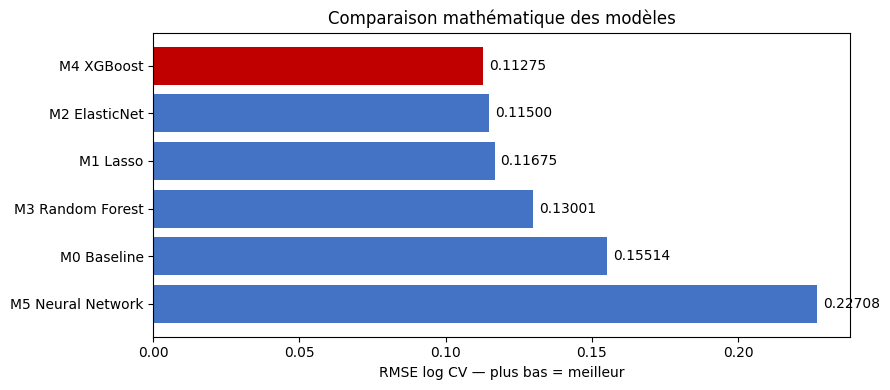

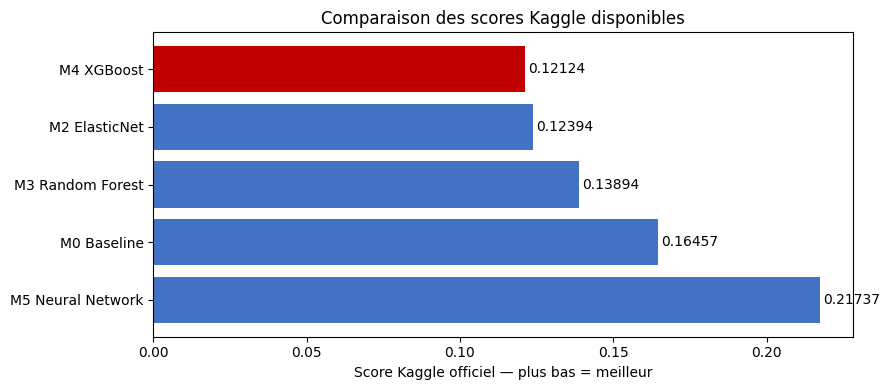

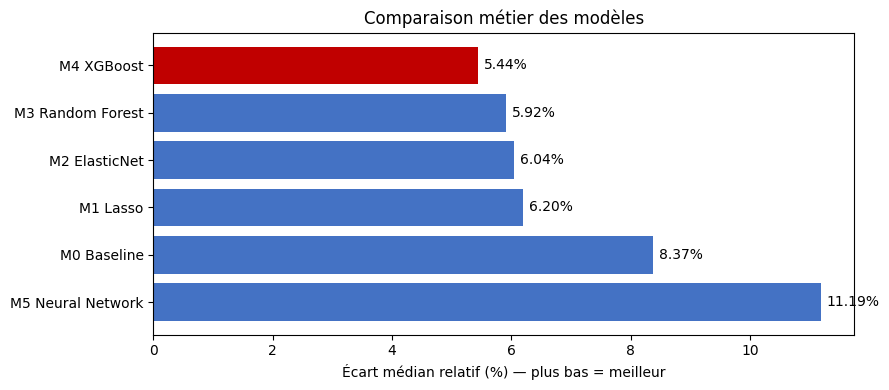

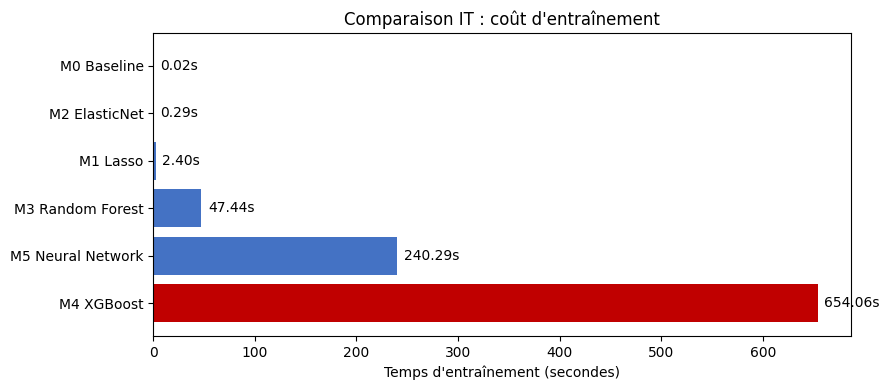

In [10]:
# Tableau consolidé des résultats du groupe
# Le tableau est défini directement dans le notebook afin qu'il s'affiche ici,
# sans dépendre d'un fichier CSV externe.
# Les métriques locales sont calculées sur train.csv.
# Les scores Kaggle viennent des soumissions officielles fournies par le groupe.

model_results = pd.DataFrame([
    {"Modèle": "M4 XGBoost",        "RMSE log (CV)": 0.11275, "Temps (s)": 654.06, "Écart médian (%)": 5.44, "MAE ($)": 13624, "R² prix réel": 0.9230, "Kaggle": 0.12124, "Source": "notebook M4 + Kaggle fourni"},
    {"Modèle": "M2 ElasticNet",     "RMSE log (CV)": 0.11500, "Temps (s)": 0.29,   "Écart médian (%)": 6.04, "MAE ($)": 14427, "R² prix réel": 0.9233, "Kaggle": 0.12394, "Source": "OOF local + Kaggle fourni"},
    {"Modèle": "M1 Lasso",          "RMSE log (CV)": 0.11675, "Temps (s)": 2.40,   "Écart médian (%)": 6.20, "MAE ($)": 14653, "R² prix réel": 0.9191, "Kaggle": np.nan, "Source": "OOF local"},
    {"Modèle": "M3 Random Forest",  "RMSE log (CV)": 0.13001, "Temps (s)": 47.44,  "Écart médian (%)": 5.92, "MAE ($)": 15639, "R² prix réel": 0.8918, "Kaggle": 0.13894, "Source": "OOF local + Kaggle fourni"},
    {"Modèle": "M0 Baseline",       "RMSE log (CV)": 0.15514, "Temps (s)": 0.02,   "Écart médian (%)": 8.37, "MAE ($)": 19779, "R² prix réel": 0.8713, "Kaggle": 0.16457, "Source": "OOF local + Kaggle fourni"},
    {"Modèle": "M5 Neural Network", "RMSE log (CV)": 0.22708, "Temps (s)": 240.29, "Écart médian (%)": 11.19,"MAE ($)": np.nan,"R² prix réel": np.nan, "Kaggle": 0.21737, "Source": "notebook M5 + Kaggle fourni"},
])

# Tri par RMSE log, car c'est la métrique mathématique principale en validation interne.
model_results = model_results.sort_values("RMSE log (CV)").reset_index(drop=True)

# Affichage direct dans le notebook.
display(
    model_results.style
    .format({
        "RMSE log (CV)": "{:.5f}",
        "Temps (s)": "{:.2f}",
        "Écart médian (%)": "{:.2f}",
        "MAE ($)": lambda x: "" if pd.isna(x) else f"{x:,.0f}".replace(",", " "),
        "R² prix réel": lambda x: "" if pd.isna(x) else f"{x:.4f}",
        "Kaggle": lambda x: "à compléter" if pd.isna(x) else f"{x:.5f}",
    })
    .hide(axis="index")
)

# Graphique 1 : critère mathématique.
fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#C00000" if m == "M4 XGBoost" else "#4472C4" for m in model_results["Modèle"]]
ax.barh(model_results["Modèle"], model_results["RMSE log (CV)"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("RMSE log CV — plus bas = meilleur")
ax.set_title("Comparaison mathématique des modèles")
for i, v in enumerate(model_results["RMSE log (CV)"]):
    ax.text(v + 0.002, i, f"{v:.5f}", va="center")
plt.tight_layout()
plt.show()

# Graphique 2 : critère Kaggle officiel.
kaggle_results = model_results.dropna(subset=["Kaggle"]).sort_values("Kaggle")
fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#C00000" if m == "M4 XGBoost" else "#4472C4" for m in kaggle_results["Modèle"]]
ax.barh(kaggle_results["Modèle"], kaggle_results["Kaggle"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("Score Kaggle officiel — plus bas = meilleur")
ax.set_title("Comparaison des scores Kaggle disponibles")
for i, v in enumerate(kaggle_results["Kaggle"]):
    ax.text(v + 0.001, i, f"{v:.5f}", va="center")
plt.tight_layout()
plt.show()

# Graphique 3 : critère métier.
business_results = model_results.sort_values("Écart médian (%)")
fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#C00000" if m == "M4 XGBoost" else "#4472C4" for m in business_results["Modèle"]]
ax.barh(business_results["Modèle"], business_results["Écart médian (%)"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("Écart médian relatif (%) — plus bas = meilleur")
ax.set_title("Comparaison métier des modèles")
for i, v in enumerate(business_results["Écart médian (%)"]):
    ax.text(v + 0.1, i, f"{v:.2f}%", va="center")
plt.tight_layout()
plt.show()

# Graphique 4 : critère IT.
it_results = model_results.sort_values("Temps (s)")
fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#C00000" if m == "M4 XGBoost" else "#4472C4" for m in it_results["Modèle"]]
ax.barh(it_results["Modèle"], it_results["Temps (s)"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("Temps d'entraînement (secondes)")
ax.set_title("Comparaison IT : coût d'entraînement")
for i, v in enumerate(it_results["Temps (s)"]):
    ax.text(v + max(it_results["Temps (s)"])*0.01, i, f"{v:.2f}s", va="center")
plt.tight_layout()
plt.show()


--- Validation holdout XGBoost — lecture métier ---
RMSE log holdout      : 0.13368
MAE prix réel         : 14,899 $
Écart médian relatif  : 5.82 %
Temps entraînement    : 0.32 secondes


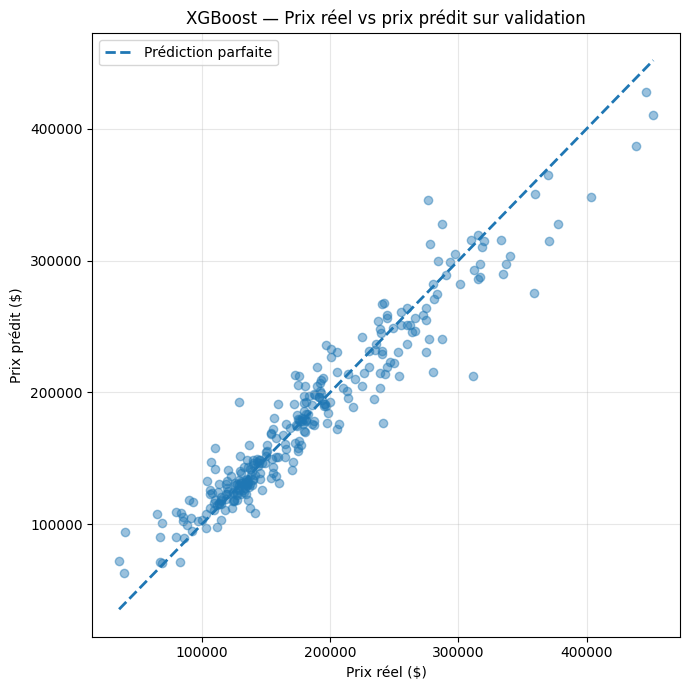

In [11]:
# Graphe demandé : prix réel vs prix prédit pour le modèle final XGBoost
# On utilise une validation holdout simple pour produire une visualisation lisible.
# La décision finale du groupe reste basée sur la validation croisée des notebooks individuels.

if XGB_AVAILABLE:
    X_train_h, X_val_h, y_train_h, y_val_h = train_test_split(
        X, y, test_size=0.20, random_state=RANDOM_STATE
    )

    xgb_holdout = clone(xgb_model)
    start = time.time()
    xgb_holdout.fit(X_train_h, y_train_h)
    holdout_time = time.time() - start

    pred_val_log = xgb_holdout.predict(X_val_h)
    pred_val_price = np.expm1(pred_val_log)
    y_val_price = np.expm1(y_val_h)

    holdout_rmse = np.sqrt(mean_squared_error(y_val_h, pred_val_log))
    holdout_mae_price = mean_absolute_error(y_val_price, pred_val_price)
    holdout_median_pct = np.median(np.abs(pred_val_price - y_val_price) / y_val_price) * 100

    print("--- Validation holdout XGBoost — lecture métier ---")
    print(f"RMSE log holdout      : {holdout_rmse:.5f}")
    print(f"MAE prix réel         : {holdout_mae_price:,.0f} $")
    print(f"Écart médian relatif  : {holdout_median_pct:.2f} %")
    print(f"Temps entraînement    : {holdout_time:.2f} secondes")

    min_axis = min(y_val_price.min(), pred_val_price.min())
    max_axis = max(y_val_price.max(), pred_val_price.max())

    plt.figure(figsize=(7, 7))
    plt.scatter(y_val_price, pred_val_price, alpha=0.45)
    plt.plot([min_axis, max_axis], [min_axis, max_axis], linestyle="--", linewidth=2, label="Prédiction parfaite")
    plt.xlabel("Prix réel ($)")
    plt.ylabel("Prix prédit ($)")
    plt.title("XGBoost — Prix réel vs prix prédit sur validation")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("XGBoost n'est pas disponible : impossible de générer le graphe prédiction vs réel.")


## Limites du score Kaggle

Le score Kaggle est utile car il permet une comparaison officielle entre les modeles sur des donnees cachees. Il donne une indication de la capacite du modele a generaliser sur de nouvelles observations.

Cependant, ce score ne suffit pas a lui seul pour choisir un modele dans un contexte bancaire.

Un modele peut obtenir un tres bon score Kaggle tout en etant :

- difficile a expliquer ;
- plus couteux a entrainer ;
- plus complexe a maintenir ;
- plus sensible aux changements du marche immobilier ;
- plus difficile a auditer dans un contexte reglemente.

C'est pourquoi le choix final ne repose pas uniquement sur le score Kaggle. Nous prenons aussi en compte les criteres metier et informatiques : l'interpretabilite, le cout de production, la stabilite du modele et la comprehension des erreurs.

Dans notre cas, le score Kaggle sert donc de critere important, mais il est complete par des metriques metier comme l'erreur moyenne en prix reel et l'ecart median d'estimation.

## 11.Choix final : pourquoi XGBoost plutôt qu'ElasticNet ?

Le choix final s'est principalement joue entre ElasticNet et XGBoost, car ce sont les deux modeles qui obtiennent les meilleurs resultats globaux du groupe.

### ElasticNet : une solution solide et interpretable

ElasticNet obtient de tres bons resultats avec un score Kaggle de 0.12394.

Ce modele presente plusieurs avantages importants dans un contexte bancaire. Il est rapide a entrainer, peu couteux a deployer et plus facilement interpretable grace a ses coefficients.

Cette interpretabilite permet d'expliquer quelles variables influencent l'estimation du prix, par exemple la surface, la qualite generale, le quartier ou l'age du bien.

ElasticNet constitue donc une solution robuste, particulierement interessante si la banque privilegie la simplicite, la transparence du modele et la facilite d'audit.

Cependant, sa structure lineaire limite sa capacite a capturer des relations complexes entre les variables. Meme avec du feature engineering, certaines interactions non lineaires entre la qualite du bien, la surface, le quartier et les equipements restent plus difficiles a modeliser.

### XGBoost : le meilleur compromis pour le modèle final

XGBoost obtient le meilleur score Kaggle du groupe avec 0.12124.

L'amelioration par rapport a ElasticNet est moderee, mais elle est coherente avec les autres criteres d'evaluation : RMSE interne, erreur metier et capacite de generalisation.

Dans un contexte bancaire, meme une amelioration limitee peut etre importante. Une estimation immobiliere trop elevee peut conduire a une mauvaise appreciation du risque hypothecaire.

Le choix de XGBoost se justifie donc par sa meilleure capacite a reduire l'erreur de prediction et a mieux capturer les relations non lineaires presentes dans les donnees.

### Arbitrage final

XGBoost est retenu car il represente le meilleur compromis entre :

- la performance mathematique ;
- la robustesse metier ;
- la capacite a modeliser des relations complexes ;
- une utilisation acceptable en production.

ElasticNet reste une alternative tres pertinente si la priorite devient l'interpretabilite, le cout de production ou la simplicite d'audit. Cependant, pour notre use case bancaire, la reduction de l'erreur d'estimation justifie le choix de XGBoost comme modele final.

# 12. Optimisation des hyperparamètres avec Optuna
*CRISP-ML — Phase 4 : Modélisation — Tuning*

Le notebook M4 utilise **Optuna** pour automatiser la recherche des meilleurs hyperparamètres XGBoost. L'objectif est d'éviter un réglage manuel et de tester efficacement plusieurs combinaisons.

## Meilleurs paramètres trouvés

| Hyperparamètre | Valeur retenue | Rôle |
|---|---:|---|
| `max_depth` | 4 | Profondeur des arbres |
| `min_child_weight` | 5 | Régularisation, limite les splits trop spécifiques |
| `learning_rate` | 0.02246 | Vitesse d'apprentissage |
| `subsample` | 0.5023 | Fraction des observations utilisées par arbre |
| `colsample_bytree` | 0.4901 | Fraction des variables utilisées par arbre |
| `reg_alpha` | 0.1154 | Régularisation L1 |
| `reg_lambda` | 0.0287 | Régularisation L2 |

Résultat obtenu dans le notebook M4 : **RMSE log CV = 0.11275**.

Le tuning est coûteux (**654.06 secondes**), mais il est réalisé hors production. Une fois le modèle choisi, seule la prédiction est utilisée par les conseillers, ce qui est beaucoup plus rapide.


# 13. Suivi des expérimentations avec MLflow
*CRISP-ML — Phase 4 : Modélisation — Traçabilité*

MLflow trace l'ensemble des expérimentations : pour chaque run, il enregistre les hyperparamètres, les métriques obtenues, le temps d'entraînement et la version du modèle. Cela garantit la **reproductibilité** et l'**auditabilité** du processus — deux exigences importantes dans un contexte bancaire.

| Information tracée | Utilité |
|---|---|
| Hyperparamètres (Optuna) | Reproduire exactement le modèle |
| RMSE log, écart médian % | Comparer objectivement les runs |
| Temps d'entraînement | Évaluer le coût opérationnel |
| Artefact modèle sérialisé | Déployer la bonne version en production |

In [12]:
# Logging MLflow — optionnel

RUN_MLFLOW = False

if RUN_MLFLOW:
    try:
        import mlflow
        mlflow.set_experiment("ames_banking_house_prices")
        for _, row in results_df.iterrows():
            with mlflow.start_run(run_name=row["Modèle"]):
                mlflow.log_metric("rmse_log_mean", row["RMSE log (mean)"])
                mlflow.log_metric("rmse_log_std",  row["RMSE log (std)"])
        print("Métriques enregistrées dans MLflow.")
    except ImportError:
        print("MLflow non installé.")
else:
    print("RUN_MLFLOW = False. Passer à True pour activer le suivi.")

RUN_MLFLOW = False. Passer à True pour activer le suivi.


# 14. Simulation de l'outil d'aide à la décision
*CRISP-ML — Phase 6 : Déploiement — Prototype*

Le modèle ne se substitue pas au conseiller bancaire. Il produit une **estimation de marché** que le conseiller utilise pour statuer. Pour couvrir le risque résiduel, la banque applique une **marge de sécurité** (X %) sur la valeur prédite.

Lorsqu'un client demande un prêt, le conseiller importe les données du bien depuis le cadastre. Le système retourne l'estimation et la décision recommandée.

L'exemple ci-dessous illustre le fonctionnement : avec une estimation de 258 000 $ et une marge de 5 %, la valeur de garantie retenue est 245 100 $. Pour un prêt demandé de 250 000 $, la décision est **REFUSÉ** — l'écart à combler est de 4 900 $.

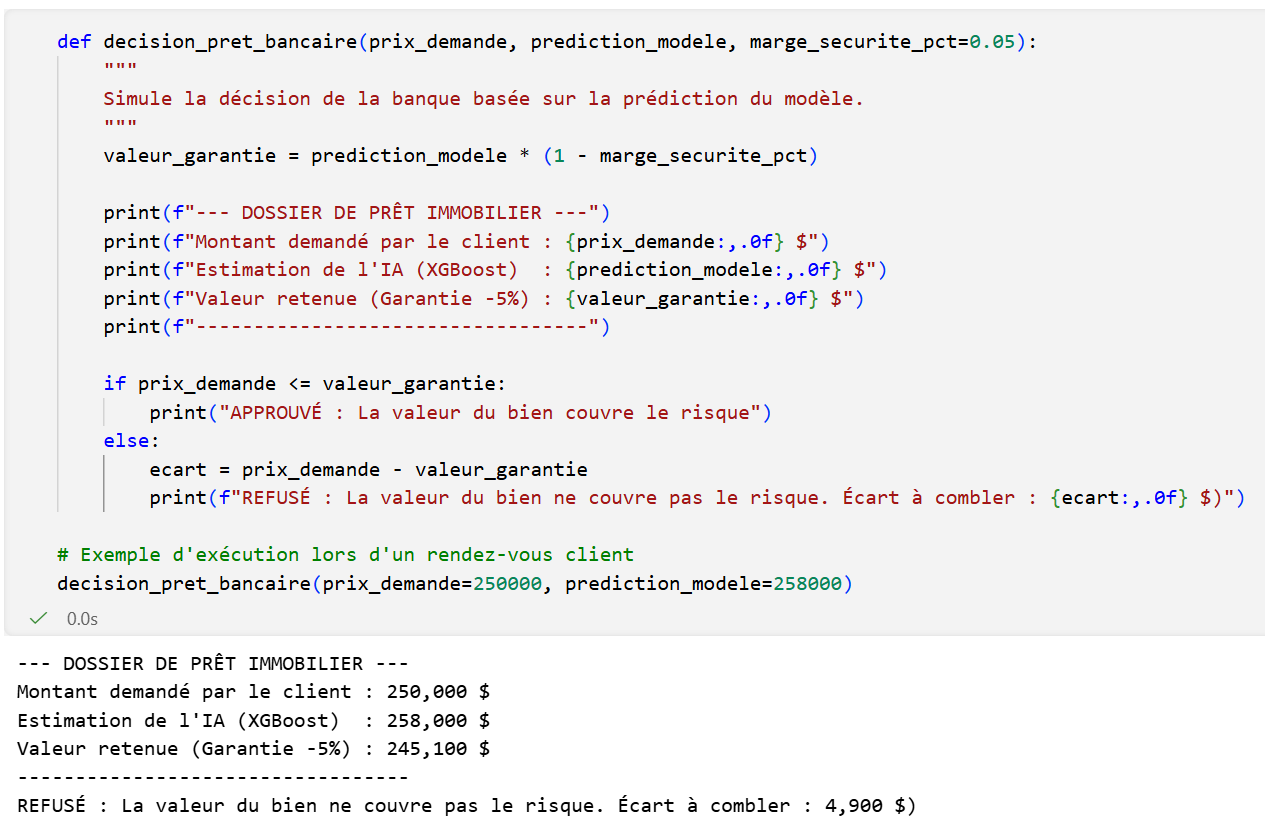

In [13]:
# Simulateur de décision bancaire

def decision_pret_bancaire(prix_demande: float, prediction_modele: float,
                            marge_securite_pct: float = 0.05) -> str:
    """
    Simule une décision bancaire basée sur la prédiction du modèle.

    prix_demande       : montant du prêt demandé par le client ($)
    prediction_modele  : estimation du prix du bien par le modèle ($)
    marge_securite_pct : marge de sécurité appliquée (défaut 5 %)
    """
    valeur_garantie = prediction_modele * (1 - marge_securite_pct)

    print("--- DOSSIER DE PRÊT IMMOBILIER ---")
    print(f"Montant demandé par le client  : {prix_demande:,.0f} $")
    print(f"Estimation de l'IA (XGBoost)   : {prediction_modele:,.0f} $")
    print(f"Valeur retenue (Garantie -{marge_securite_pct:.0%}) : {valeur_garantie:,.0f} $")
    print("----------------------------------")

    if prix_demande <= valeur_garantie:
        print("APPROUVÉ : La valeur du bien couvre le risque")
    else:
        ecart = prix_demande - valeur_garantie
        print(f"REFUSÉ : La valeur du bien ne couvre pas le risque. Écart à combler : {ecart:,.0f} $")


# Exemple d'exécution lors d'un rendez-vous client
decision_pret_bancaire(prix_demande=250000, prediction_modele=258000)

--- DOSSIER DE PRÊT IMMOBILIER ---
Montant demandé par le client  : 250,000 $
Estimation de l'IA (XGBoost)   : 258,000 $
Valeur retenue (Garantie -5%) : 245,100 $
----------------------------------
REFUSÉ : La valeur du bien ne couvre pas le risque. Écart à combler : 4,900 $


# 15. Entraînement final et prédiction
*CRISP-ML — Phase 6 : Déploiement*

Après sélection du modèle, XGBoost est entraîné sur l'**intégralité du jeu d'entraînement** pour maximiser la quantité de données disponibles. Les prédictions sur `test.csv` sont reconverties en dollars via `np.expm1` et exportées au format Kaggle.

In [14]:
# Entraînement final sur 100% du train — optionnel dans ce notebook de synthèse
# Les résultats officiels de M4 proviennent du notebook XGBoost optimisé.
# Ici, on désactive par défaut l'entraînement final pour garder le notebook rapide à exécuter.
# Pour générer une soumission depuis ce notebook, passer RUN_FINAL_SUBMISSION = True dans la cellule d'import.

if XGB_AVAILABLE and RUN_FINAL_SUBMISSION:
    start = time.time()
    xgb_model.fit(X, y)
    print(f"Modèle entraîné en {time.time() - start:.1f} secondes.")

    test_preds = np.expm1(xgb_model.predict(X_test))
    print(f"Prédictions : {len(test_preds)} | "
          f"Min : {test_preds.min():,.0f} $ | Max : {test_preds.max():,.0f} $ | "
          f"Médiane : {np.median(test_preds):,.0f} $")
else:
    print("Entraînement final désactivé dans le notebook de synthèse (RUN_FINAL_SUBMISSION = False).")


Entraînement final désactivé dans le notebook de synthèse (RUN_FINAL_SUBMISSION = False).


In [15]:
# Top 15 des variables les plus importantes — XGBoost
# Cette cellule s'exécute seulement si le modèle final a été entraîné dans ce notebook.

if XGB_AVAILABLE and RUN_FINAL_SUBMISSION and "test_preds" in globals():
    num_out = numeric_features
    cat_out = categorical_features
    feature_names = num_out + cat_out

    importances = xgb_model.named_steps["model"].feature_importances_

    importance_df = pd.DataFrame({
        "Variable": feature_names,
        "Importance": importances
    }).sort_values("Importance", ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ["#C00000" if i == 0 else "#4472C4" for i in range(len(importance_df))]
    ax.barh(importance_df["Variable"][::-1], importance_df["Importance"][::-1], color=colors[::-1])
    ax.set_xlabel("Importance relative (gain)")
    ax.set_title("Top 15 des variables les plus importantes — XGBoost final")
    plt.tight_layout()
    plt.show()

    print("\nTop 5 :")
    print(importance_df[["Variable", "Importance"]].head(5).to_string(index=False))
else:
    print("Importance non calculée ici : entraînement final désactivé dans le notebook de synthèse.")

Importance non calculée ici : entraînement final désactivé dans le notebook de synthèse.


In [16]:
# Export de la soumission Kaggle — optionnel
# Le fichier officiel de soumission XGBoost doit être généré depuis le notebook M4 complet.
# Cette cellule est conservée pour montrer le format Kaggle attendu.

if XGB_AVAILABLE and RUN_FINAL_SUBMISSION and test_ids is not None and "test_preds" in globals():
    submission = pd.DataFrame({"Id": test_ids, "SalePrice": test_preds})
    fichier = "submission_xgboost_ames_banking.csv"
    submission.to_csv(fichier, index=False)
    print(f"Fichier '{fichier}' prêt.")
    display(submission.head())
else:
    print("Export Kaggle non généré ici. Utiliser le notebook M4 complet ou passer RUN_FINAL_SUBMISSION = True.")


Export Kaggle non généré ici. Utiliser le notebook M4 complet ou passer RUN_FINAL_SUBMISSION = True.


# 16. Production et monitoring
*CRISP-ML — Phase 6 : Déploiement — Vision long terme*

## Déploiement via API

Le pipeline sérialisé (via `joblib`) peut être encapsulé dans une API REST. Le système d'information de la banque enverrait les caractéristiques d'un bien en JSON et recevrait l'estimation et la décision recommandée :

```
[SI Banque] → POST /predict {features} → [API XGBoost] → {prix_estimé, valeur_garantie, décision}
```

## Monitoring MLOps

Le marché immobilier évolue constamment avec les taux d'intérêt et l'inflation. Sans monitoring, un modèle figé se dégrade silencieusement. La cadence recommandée est une surveillance mensuelle des métriques et un réentraînement tous les 6 mois.

Deux types de dérive sont à surveiller :

| Type | Description | Signal d'alerte |
|---|---|---|
| **Data drift** | Les distributions des variables d'entrée changent | Test KS sur les features en production |
| **Concept drift** | La relation variables → prix change | Dégradation du RMSE sur nouvelles observations |

## Explicabilité avec SHAP

Dans un contexte bancaire, un client refusé a le droit de comprendre pourquoi. SHAP (*SHapley Additive exPlanations*) permet de décomposer chaque prédiction en contributions par variable, compatible avec XGBoost via `shap.TreeExplainer`.

## Interface conseiller

Un tableau de bord (PowerBI ou Streamlit) mettrait à disposition des conseillers l'estimation du modèle, la marge de sécurité appliquée, la décision recommandée et les principales variables ayant influencé l'estimation.

# 17. Conclusion
*CRISP-ML — Synthèse*

Ce projet montre qu'une démarche CRISP-ML permet de passer d'un dataset brut à un outil d'aide à la décision bancaire.

La baseline M0 a fourni un point de départ commun avec un **RMSE log de 0.15514** et un score Kaggle de **0.16457**. Les modèles plus avancés ont ensuite permis de réduire fortement l'erreur. ElasticNet a donné une solution très compétitive et interprétable (**RMSE log 0.11500**, score Kaggle observé **0.12394**). XGBoost a finalement été retenu car il obtient le meilleur compromis global : **RMSE log 0.11275**, **score Kaggle 0.12124**, **MAE 13 624 $**, **R² 0.9230** et **écart médian métier 5.44 %**.

## Synthèse des décisions clés

| Décision | Choix retenu | Justification |
|---|---|---|
| Méthode projet | CRISP-ML | Imposé |
| Baseline | M0 régression linéaire | Point de comparaison commun |
| Transformation cible | `log1p(SalePrice)` | Cohérent avec Kaggle et limite l'effet des maisons très chères |
| Nettoyage | Retrait des outliers `GrLivArea > 4000` et `SalePrice < 300000` | Anomalies documentées qui perturbent la relation surface-prix |
| Encodage | Ordinal + Target Encoding | Respecte les ordres métier et évite l'explosion de colonnes |
| Modèle final | XGBoost | Meilleure performance mathématique, métier et Kaggle |
| Alternative robuste | ElasticNet | Plus simple, plus interprétable, moins coûteux, et score Kaggle proche |

## Limites

Le modèle reste entraîné sur un dataset historique et localisé à Ames. En production réelle, il faudrait surveiller les dérives du marché immobilier, vérifier l'équité des prédictions entre quartiers et organiser un réentraînement régulier.

## Décision finale

Pour un prototype bancaire, **XGBoost** est retenu comme modèle final. Son coût d'entraînement plus élevé est acceptable, car il est compensé par une meilleure précision et une meilleure réduction du risque d'erreur d'estimation, malgré un temps d’entraînement plus élevé (654.06 s, optimisation incluse).
